In [1]:
# System and path configuration
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
# Add parent directory to path for module imports
sys.path.insert(0, os.path.abspath('../..'))

# Core LSD imports
from codes.lsd_train import LSD
from codes.utils import (
    plot_random_walks,
    cross_boundary_correctness
)
from codes.config import LSDConfig
# Scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import torch
import torch.nn as nn
import pyro

# Single-cell analysis
import scanpy as sc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
#read the adata
data_path = "/home/saberi/projects/lsd/data/Zebrafish/perturb_train_adata.h5ad"
adata = sc.read(data_path)

#intialize LSD model
cfg = LSDConfig()
cfg.model.layer_dims.potential = [16,16]
lsd = LSD(
    adata,
    cfg,
    device=device,
    lib_size_key="librarysize",
    raw_count_key="raw"
)

#load the trained model
model_dir = "../../Models/Zebrafish_model"
model_path = "lsd_model_epoch0030.pth"
lsd.load(model_dir, model_path)

#extract LSD outputs (transition matrix, potantial, entropy, pseudotime)
final_adata = lsd.get_adata()

#predict cell fates
dyn_adata = lsd.get_cell_fates(final_adata , time_range = 20, cluster_key = "clusters")

[LSD] Model and Pyro parameters loaded from ../../Models/Zebrafish_model/lsd_model_epoch0030.pth


plotting LSD outputs on force directed projection


/home/saberi/miniconda/envs/sclsd/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


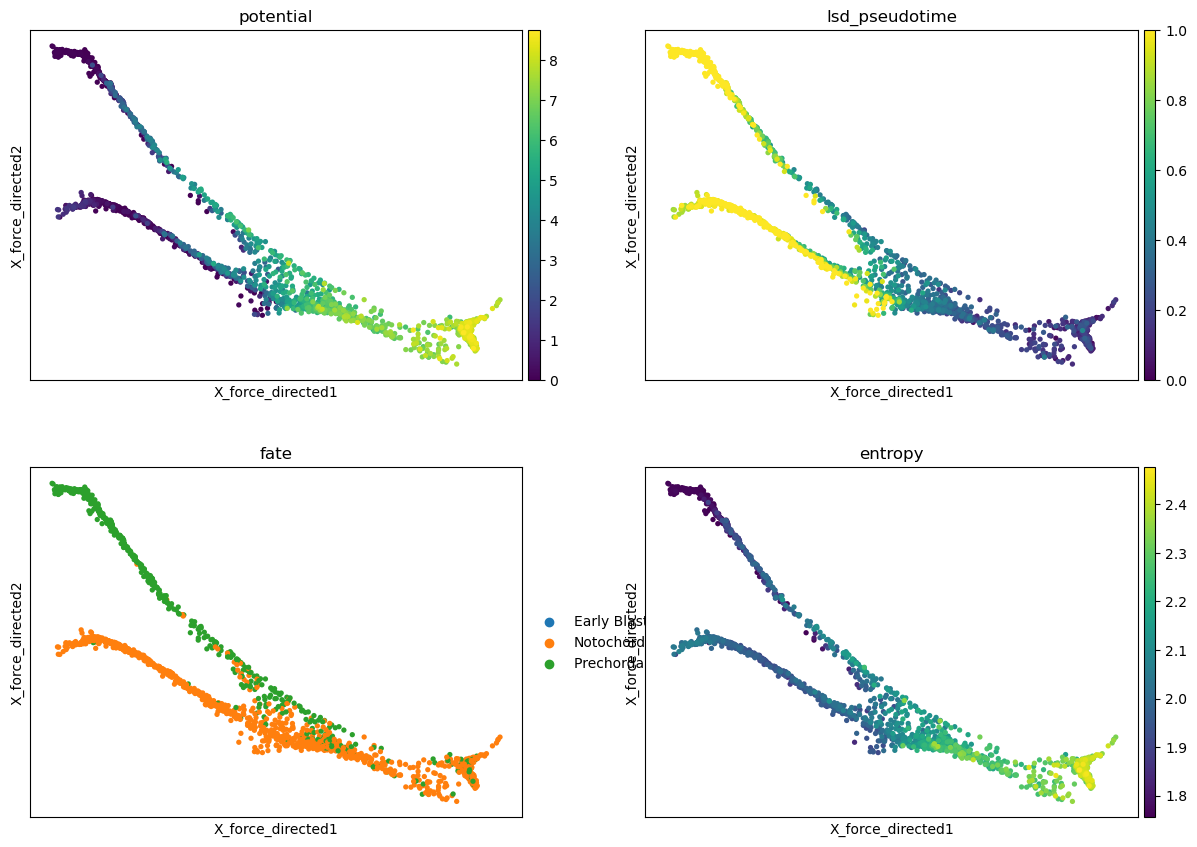

plotting LSD outputs on diffrentiation state projection


/home/saberi/miniconda/envs/sclsd/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


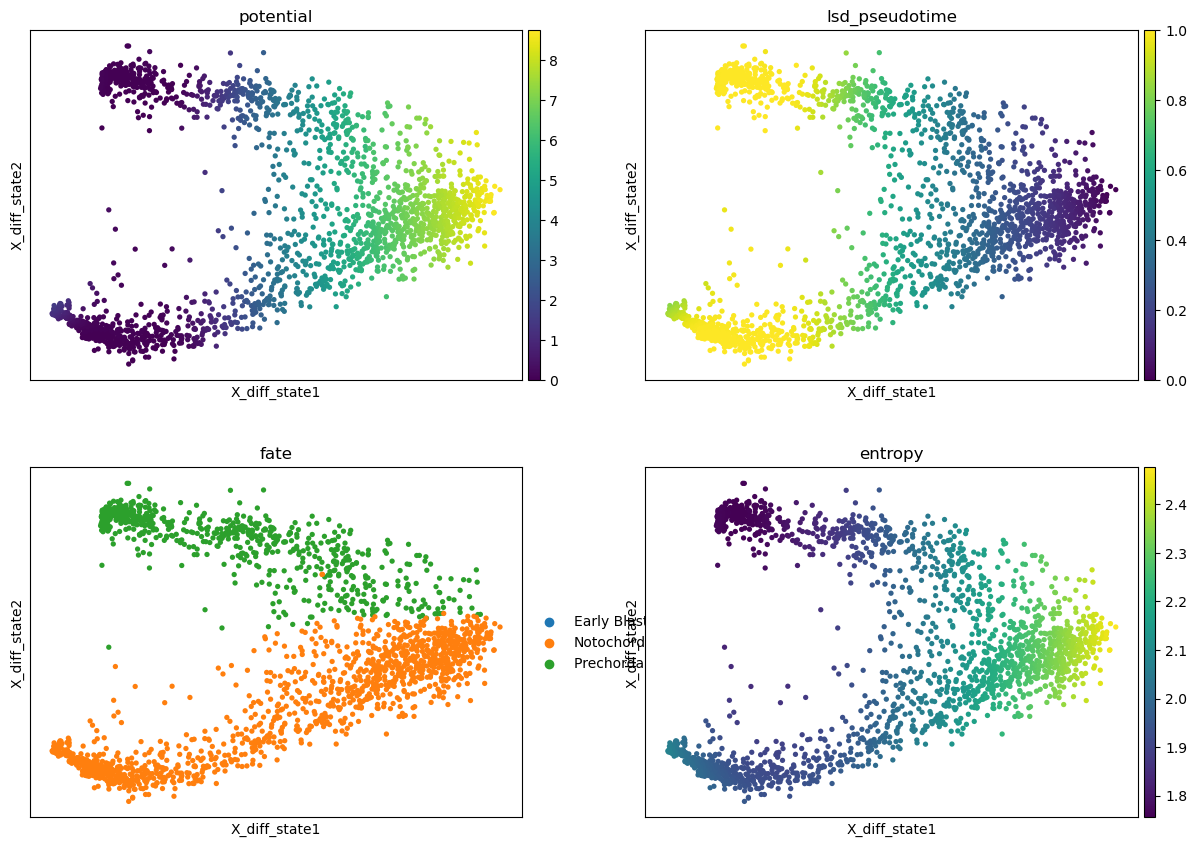

plotting LSD streamlines on force directed projection


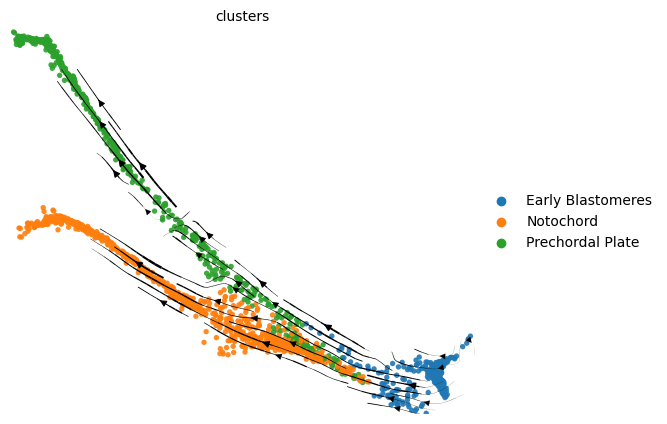

plotting LSD streamlines on diffrentiation state projection


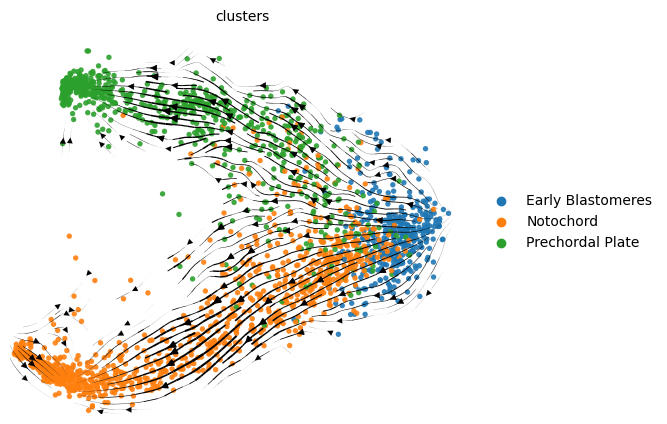

<Axes: title={'center': 'clusters'}>

In [3]:
#plot lsd outputs
dyn_adata.obs["clusters"] = dyn_adata.obs["lineages"]
cols = ["potential", "lsd_pseudotime", "fate", "entropy"]

print("="* 60)
print("plotting LSD outputs on force directed projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_force_directed", ncols = 2)

print("="* 60)
print("plotting LSD outputs on diffrentiation state projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_diff_state", ncols = 2)

print("="* 60)
print("plotting LSD streamlines on force directed projection")
print("="* 60)
lsd.stream_lines(embedding= "X_force_directed", size = 60)

print("="* 60)
print("plotting LSD streamlines on diffrentiation state projection")
print("="* 60)
lsd.stream_lines(embedding= "X_diff_state", size = 60)

In [4]:
x = torch.from_numpy(dyn_adata.X.toarray()) 
#run perturbation sweep over levels 0..max_pert --- for noto gene
all_levels_fates = []
levels = list(range(1, 10 + 1))

for lvl in levels:
    pert_fates, unpert_fates = lsd.perturb(adata=dyn_adata,x=x, gene_name="NOTO", cluster_key = "clusters",
                                           max_perturbations= lvl, batch_size = 2048)
    all_levels_fates.append(np.asarray(pert_fates, dtype=object))
baseline_fate = np.asarray(unpert_fates, dtype=object)

# 2) Encode fates as integer codes for fast comparison across levels
all_unique_fates = pd.Index(np.unique(np.concatenate(all_levels_fates + [baseline_fate])))
fate_to_code = {f: i for i, f in enumerate(all_unique_fates)}

code_levels = np.vstack([np.vectorize(fate_to_code.get)(f) for f in all_levels_fates])  # (L, n_cells)
baseline_codes = np.vectorize(fate_to_code.get)(baseline_fate)                          # (n_cells,)

# 3) Per-cell: first level where fate differs from baseline, fate at that level, and total flips
chg_vs_base = code_levels != baseline_codes[None, :]          # (L, n_cells)
any_change = chg_vs_base.any(axis=0)                          # (n_cells,)

first_idx0 = np.argmax(chg_vs_base, axis=0)                   # 0..L-1 (meaningful only if any_change)
first_change_level = np.where(any_change, first_idx0 + 1, -1) # 1..L, else -1 = unchanged

fate_at_first_change = np.where(
    any_change,
    np.array([all_levels_fates[first_idx0[i]][i] for i in range(len(first_idx0))], dtype=object),
    baseline_fate,  # unchanged -> baseline
)

# total number of flips across successive perturbation levels (level1->level2->...->levelL)
total_changes = np.sum(code_levels[1:, :] != code_levels[:-1, :], axis=0) if len(all_levels_fates) > 1 else 0

change_status = np.where(first_change_level == -1, "unchanged",
                         np.array([f"changed_at_{lv}" for lv in first_change_level], dtype=object))

# 4) Summary dataframe
summary_df = pd.DataFrame({
    "cell_id": dyn_adata.obs_names.values,
    "cluster": dyn_adata.obs["clusters"].astype(str).values,
    "baseline_fate": baseline_fate,
    "lsd_pseudotime": dyn_adata.obs["lsd_pseudotime"].values,
    "first_change_level": first_change_level,          # -1 => unchanged up to max_pert
    "fate_at_first_change": fate_at_first_change,      # equals baseline if unchanged
    "final_fate": all_levels_fates[-1],                # fate at max_pert
    "total_changes": np.asarray(total_changes, dtype=int),
    "change_status": change_status,
})


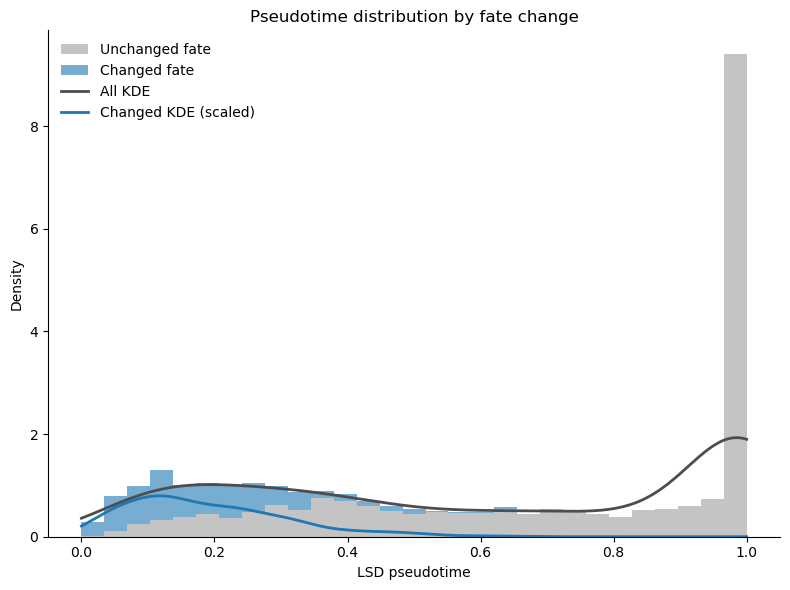

In [5]:
#plot the distribution of cell fate changes after noto perturbation across pseudotime
from scipy.stats import gaussian_kde

# Split pseudotime by fate change
changed = summary_df.loc[summary_df.first_change_level != -1, "lsd_pseudotime"].dropna().values
unchanged = summary_df.loc[summary_df.first_change_level == -1, "lsd_pseudotime"].dropna().values
all_vals = np.r_[changed, unchanged]

# Binning
bins = np.linspace(all_vals.min(), all_vals.max(), 30)
x = np.linspace(all_vals.min(), all_vals.max(), 500)

plt.figure(figsize=(8, 6))

# Stacked histogram
plt.hist(
    [unchanged, changed],
    bins=bins,
    density=True,
    stacked=True,
    alpha=0.6,
    color=["#9e9e9e", "#1f77b4"],
    label=["Unchanged fate", "Changed fate"],
)

# KDEs
plt.plot(x, gaussian_kde(all_vals)(x), color="0.3", lw=2, label="All KDE")
plt.plot(
    x,
    gaussian_kde(changed)(x) * (len(changed) / len(all_vals)),
    color="#1f77b4",
    lw=2,
    label="Changed KDE (scaled)",
)

plt.xlabel("LSD pseudotime")
plt.ylabel("Density")
plt.title("Pseudotime distribution by fate change")
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


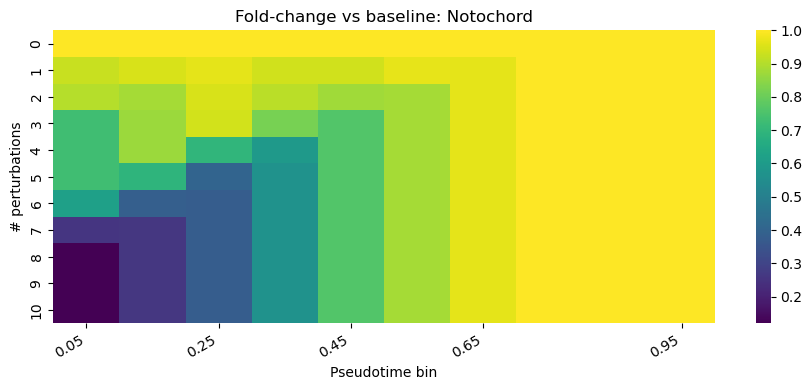

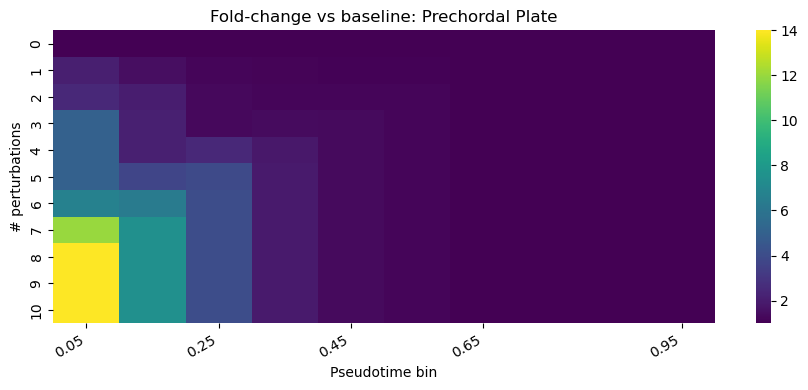

In [6]:
#plot the frequency heatmap for cell fate changes across noto perturbation iterations and pseudotime bins.
# --- Inputs ---
n_bins = 10
max_pert = 10

baseline_fate = summary_df["baseline_fate"].to_numpy(dtype=object)
final_fate    = summary_df["final_fate"].to_numpy(dtype=object)
first_lvl     = summary_df["first_change_level"].to_numpy()          # -1 => unchanged
pt            = summary_df["lsd_pseudotime"].to_numpy(dtype=float)

# --- Bin pseudotime ---
edges   = np.linspace(pt.min(), pt.max(), n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
bin_idx = np.clip(np.digitize(pt, edges) - 1, 0, n_bins - 1)

# --- Fate at each perturbation level (level 0 = baseline) ---
level_fates = [baseline_fate]
for lvl in range(1, max_pert + 1):
    level_fates.append(np.where((first_lvl != -1) & (lvl >= first_lvl), final_fate, baseline_fate))

def fold_change_mat(target):
    # freq[level, bin] of target fate
    freq = np.full((max_pert + 1, n_bins), np.nan, dtype=float)
    for lvl in range(max_pert + 1):
        f = level_fates[lvl]
        for b in range(n_bins):
            m = (bin_idx == b)
            denom = m.sum()
            if denom:
                freq[lvl, b] = np.mean(f[m] == target)

    # fold-change vs baseline per bin
    base = freq[0, :]
    with np.errstate(divide="ignore", invalid="ignore"):
        fc = freq / base[None, :]
    fc[np.isinf(fc)] = np.nan
    return pd.DataFrame(fc, index=range(max_pert + 1), columns=range(n_bins))

# --- Plot heatmaps ---
for target in ["Notochord", "Prechordal Plate"]:
    mat = fold_change_mat(target)
    plt.figure(figsize=(9, 4))
    sns.heatmap(mat, cmap="viridis", cbar=True)
    plt.title(f"Fold-change vs baseline: {target}")
    plt.xlabel("Pseudotime bin")
    plt.ylabel("# perturbations")
    # label a few bins with pseudotime centers
    xt = np.linspace(0, n_bins - 1, 5, dtype=int)
    plt.xticks(xt + 0.5, [f"{centers[i]:.2f}" for i in xt], rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


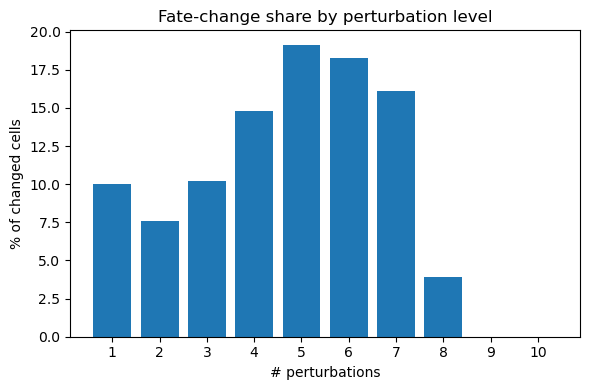

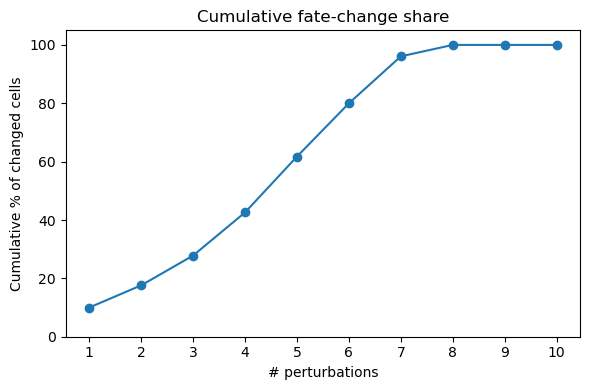

In [7]:
#plotting the frequency of cells that change their fate after noto perturbation across pseudotime
max_pert = 10

# counts per first-change level (among changed cells only)
lvl = summary_df.loc[summary_df.first_change_level != -1, "first_change_level"]
fate_change_percent = (
    lvl.value_counts()
       .reindex(range(1, max_pert + 1), fill_value=0)
       .sort_index()
       .rename_axis("perturbation_level")
       .reset_index(name="n_changed_cells")
)
fate_change_percent["percent_of_changed"] = 100 * fate_change_percent["n_changed_cells"] / len(lvl)

# bar: % share per level
plt.figure(figsize=(6, 4))
plt.bar(fate_change_percent["perturbation_level"], fate_change_percent["percent_of_changed"])
plt.xlabel("# perturbations")
plt.ylabel("% of changed cells")
plt.title("Fate-change share by perturbation level")
plt.xticks(range(1, max_pert + 1))
plt.tight_layout()
plt.show()

# line: cumulative %
plt.figure(figsize=(6, 4))
plt.plot(fate_change_percent["perturbation_level"],
         fate_change_percent["percent_of_changed"].cumsum(),
         marker="o")
plt.xlabel("# perturbations")
plt.ylabel("Cumulative % of changed cells")
plt.title("Cumulative fate-change share")
plt.xticks(range(1, max_pert + 1))
plt.ylim(0, 105)
plt.tight_layout()
plt.show()


In [10]:
# List of genes to keep
genes_to_keep = ['ACCS', 'ADNP2A', 'ADNPA', 'ADNPB', 'AEBP2']

# Filter adata.var_names
adata = adata[:, adata.var_names.isin(genes_to_keep)]

In [11]:
#large scale gene KO for early balstomeres
rows = []
x = torch.from_numpy(dyn_adata.X.toarray()) 
idx = np.where(dyn_adata.obs['clusters'] == "Early Blastomeres")[0]
IC = x[idx].to(device)
from tqdm.notebook import tqdm
for i, gene in enumerate(tqdm(adata.var_names, 
                              desc="Perturbing genes",
                              total=len(adata.var_names))):
    perturbed_fates, unperturbed_fates = lsd.perturb(
    adata=dyn_adata,
    x=IC,
    gene_name=gene,
    cluster_key="clusters",
    batch_size= 4096
    )

    # Count fate outcomes
    pert_count_noto = np.sum(perturbed_fates == "Notochord")
    unpert_count_noto = np.sum(unperturbed_fates == "Notochord")
    pert_count_pre = np.sum(perturbed_fates == "Prechordal Plate")
    unpert_count_pre = np.sum(unperturbed_fates == "Prechordal Plate")

    # Calculate log fold changes
    # Add pseudocount to avoid division by zero
    pseudocount = 0
    logFC_noto = np.log2((pert_count_noto + pseudocount) / (unpert_count_noto + pseudocount))
    logFC_pre = np.log2((pert_count_pre + pseudocount) / (unpert_count_pre + pseudocount))

    # Store results
    rows.append({
    "Gene": gene,
    "Perturbed_Notochord_count": pert_count_noto,
    "Unperturbed_Notochord_count": unpert_count_noto,
    "Perturbed_Prechordal_count": pert_count_pre,
    "Unperturbed_Prechordal_count": unpert_count_pre,
    "Notochord_LogFC": logFC_noto,
    "Prechordal_LogFC": logFC_pre,
    "Total_cells": len(IC)
    })
df = pd.DataFrame(rows)

Perturbing genes:   0%|          | 0/5 [00:00<?, ?it/s]

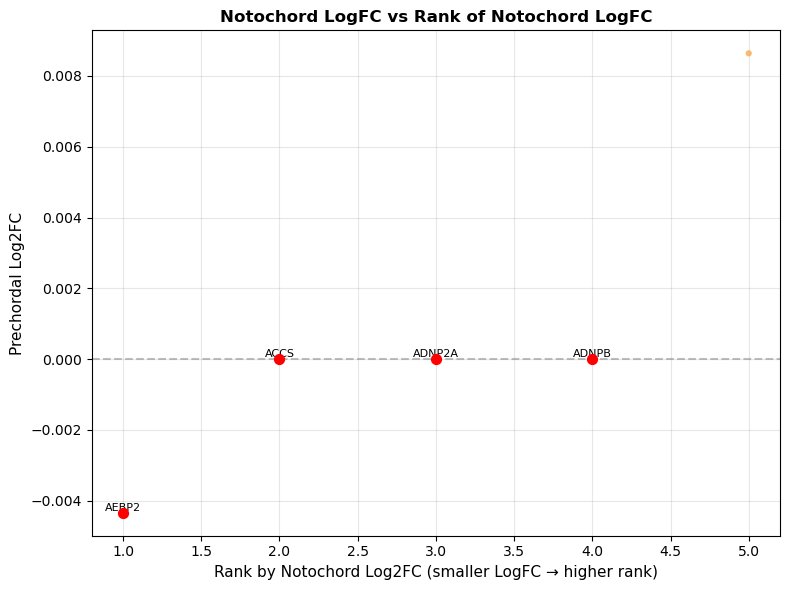

In [12]:
# Rank genes: smaller Notochord_LogFC = higher rank
df_clean = df.dropna()
df_ranked = df_clean.copy()
df_ranked['Noto_Rank'] = df_ranked['Notochord_LogFC'].rank(method='first', ascending=True).astype(int)
df_ranked = df_ranked.sort_values('Noto_Rank')
top_noto_negative = df_clean.nsmallest(4, 'Notochord_LogFC')[['Gene', 'Notochord_LogFC']]
# Create figure
plt.figure(figsize=(8, 6))

# Scatter plot: Prechordal_LogFC vs Rank(Notochord_LogFC)
plt.scatter(df_ranked['Noto_Rank'], df_ranked['Notochord_LogFC'],
            alpha=0.6, s=20, c='darkorange', edgecolor='none')

# Highlight top genes (if you want — optional)
top_genes_noto = pd.concat([top_noto_negative.head(4)])
if 'Gene' in df_ranked.columns:
    mark_df = df_ranked[df_ranked['Gene'].isin(top_genes_noto['Gene'])]
    plt.scatter(mark_df['Noto_Rank'], mark_df['Notochord_LogFC'],
                color='red', s=50, zorder=5)
    for _, row in mark_df.iterrows():
        plt.annotate(row['Gene'],
                     (row['Noto_Rank'], row['Notochord_LogFC']),
                     fontsize=8, ha='center', va='bottom')

# Reference line at y=0
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Labels & title
plt.xlabel('Rank by Notochord Log2FC (smaller LogFC → higher rank)', fontsize=11)
plt.ylabel('Prechordal Log2FC', fontsize=11)
plt.title('Notochord LogFC vs Rank of Notochord LogFC', fontsize=12, fontweight='bold')

# Styling
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


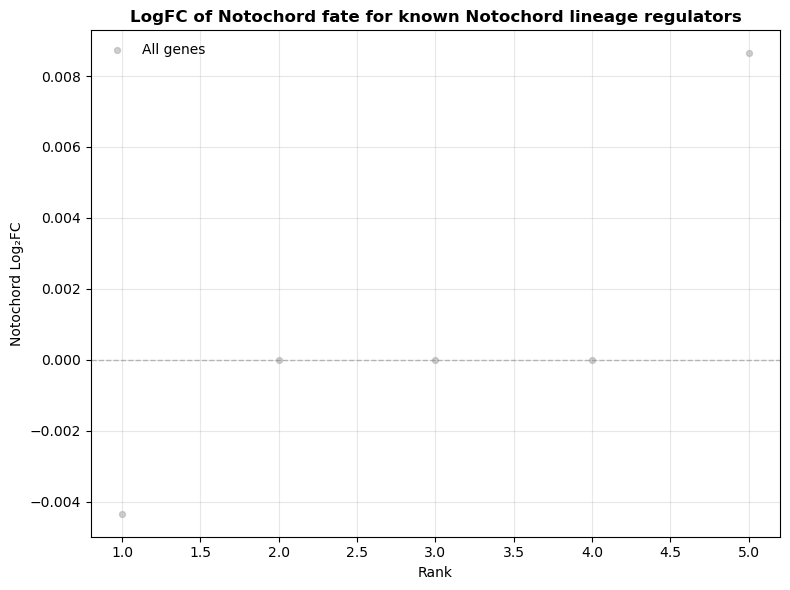

In [13]:
# Known TFs to annotate
known_tfs = [
    "FOXA2", "SP5L", "NOTO", "CREB3L2", "EVE1", "HER6", "JUN",
    "CDX4", "LEF1", "FOXA", "TWIST2", "SOX2", "SP5A"
]
# Known TFs to annotate
known_tfs = [
    "FOXA2", "SP5L", "NOTO", "CREB3L2", "EVE1", "HER6", "JUN",
    "CDX4", "LEF1", "FOXA", "TWIST2", "SOX2", "SP5A"
]

# Subset to genes that are actually present in the ranked DF
tfs_df = df_ranked[df_ranked["Gene"].isin(known_tfs)].copy()
# (Optional) sort by rank for nicer annotation order
tfs_df = tfs_df.sort_values("Noto_Rank")

# Make figure
fig, ax = plt.subplots(figsize=(8, 6))

# All genes (non-annotated) in grey
ax.scatter(
    df_ranked["Noto_Rank"],
    df_ranked["Notochord_LogFC"],
    color="#b0b0b0",      # grey
    alpha=0.6,
    s=18,
    rasterized=True,
    label="All genes",
)

# Highlight known regulators in blue and annotate
if not tfs_df.empty:
    ax.scatter(
        tfs_df["Noto_Rank"],
        tfs_df["Notochord_LogFC"],
        color="#1f77b4",   # blue
        s=50,
        zorder=3,
        rasterized=True,
        label="Known Notochord regulators",
    )

    # Stagger labels vertically to reduce overlap
    for j, (_, row) in enumerate(tfs_df.iterrows()):
        label = f"{row['Gene']} (rank {row['Noto_Rank']})"
        # Create a repeating pattern of vertical offsets
        y_offset = (j % 4 - 1.5) * 8  # -12, -4, 4, 12 points
        ax.annotate(
            label,
            (row["Noto_Rank"], row["Notochord_LogFC"]),
            fontsize=8,
            ha="center",
            va="bottom",
            xytext=(0, 6 + y_offset),
            textcoords="offset points",
            arrowprops=dict(
                arrowstyle="-",
                lw=0.5,
                color="black",
                alpha=0.6,
            ),
        )

ax.axhline(0, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Rank")
ax.set_ylabel("Notochord Log\u2082FC")
ax.set_title("LogFC of Notochord fate for known Notochord lineage regulators", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()

plt.show()

In [14]:
#enrichment analysis
#step 1, fitting a NB distribution to logFC changes
import pyro
import pyro.distributions as dist
import torch
from pyro.infer import SVI, TraceMeanField_ELBO
from pyro.infer.autoguide import AutoDelta  # or AutoNormal for a variational posterior
from pyro.optim import Adam

# Assume 'data' is your 1D NumPy array of counts, e.g.:
data = df_clean["Perturbed_Notochord_count"].values
data_tensor = torch.tensor(data, dtype=torch.float)

def model(data):
    # Define priors for the NB parameters.
    # total_count: shape parameter (we use a Gamma prior so that it stays positive)
    total_count = pyro.sample("total_count", dist.Gamma(2.0, 1.0))
    # probs: probability parameter (constrained to (0, 1))
    probs = pyro.sample("probs", dist.Beta(1.0, 1.0))
    
    # Plate over the observed data.
    with pyro.plate("data_plate", len(data)):
        # The likelihood: Negative Binomial likelihood for each observation.
        pyro.sample("obs", dist.NegativeBinomial(total_count, probs), obs=data)

# Use an AutoDelta guide for MAP estimates; you could also try AutoNormal.
guide = AutoDelta(model)

# Set up the optimizer and SVI object.
optimizer = Adam({"lr": 0.1})
svi = SVI(model, guide, optimizer, loss=TraceMeanField_ELBO())

# Run the inference loop.
num_steps = 5000
for step in range(num_steps):
    loss = svi.step(data_tensor)
    if step % 1000 == 0:
        print(f"Step {step} : loss = {loss}")

# Extract the inferred parameters.
inferred_params = guide.median()
inferred_total_count = inferred_params["total_count"]
inferred_probs = inferred_params["probs"]

print("Inferred total_count:", inferred_total_count)
print("Inferred probs:", inferred_probs)



Step 0 : loss = 2056.0439453125
Step 1000 : loss = 32.940185546875
Step 2000 : loss = 32.89705276489258
Step 3000 : loss = 32.89692687988281
Step 4000 : loss = 32.89708709716797
Inferred total_count: tensor(3.5885)
Inferred probs: tensor(0.9893)


In [15]:
#step 2, extracting the p-value for each gene
from scipy.stats import nbinom
r = float(inferred_total_count.item() if hasattr(inferred_total_count, "item") else inferred_total_count)
p = float(1 - inferred_probs.item() if hasattr(inferred_probs, "item") else 1 - inferred_probs)
df_clean["-log_p_val"] = -np.log(nbinom.cdf(df["Perturbed_Notochord_count"].values, r, p))
rnk = df_clean[['Gene', '-log_p_val']]
rnk = rnk.dropna()
rnk = rnk.set_index('Gene')['-log_p_val']
# sort by logFC
rnk = rnk.sort_values(ascending=False)

In [17]:
#step3, performing preranked enrichment analysis
import gseapy as gp
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets=[
    'GO_Biological_Process_2021', 
    'Reactome_Pathways_2024'],
    organism='Zebrafish',
    permutation_num=1000,  # for stable p-values
    seed=42
)
terms = pre_res.res2d.Term
# Get top 5 pathways
top_5_terms = pre_res.res2d.Term.head(5).tolist()

# Create a comprehensive dataframe
gene_pathway_data = []

for term in top_5_terms:
    # Get the RES scores for this pathway
    res_scores = pre_res.results[term]["RES"]
    
    # Get gene names and -log_p_val from rnk (assuming rnk is your ranking dataframe)
    # rnk should have genes as index and -log_p_val as values
    
    # Iterate through all genes in the ranking
    for i, (gene, log_p_val) in enumerate(rnk.iterrows() if hasattr(rnk, 'iterrows') else enumerate(rnk.items())):
        if hasattr(rnk, 'iterrows'):
            gene_name = gene
            neg_log_p_val = log_p_val.iloc[0] if hasattr(log_p_val, 'iloc') else log_p_val
        else:
            gene_name = gene
            neg_log_p_val = log_p_val
            
        # Get corresponding RES score (RES array has same length as gene ranking)
        res_score = res_scores[i] if i < len(res_scores) else 0
        
        gene_pathway_data.append({
            'Pathway': term,
            'Gene': neg_log_p_val[0],
            'Rank': i + 1,
            'neg_log_p_val': neg_log_p_val[1],
            'RES': res_score
        })

# Create the final dataframe
gene_es_df = pd.DataFrame(gene_pathway_data)

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

# Get unique pathways
pathways = gene_es_df['Pathway'].unique()[:5]  # Top 5 pathways

# Create a combined plot showing all pathways
fig2, ax2 = plt.subplots(1, 1, figsize=(12, 8))

# Plot all pathways on the same graph with different colors
colors = plt.cm.Set1(np.linspace(0, 1, len(pathways)))

for i, pathway in enumerate(pathways):
    pathway_data = gene_es_df[gene_es_df['Pathway'] == pathway].copy()
    pathway_data = pathway_data.sort_values('Rank')
    
    # Use full pathway name for legend (will wrap automatically)
    ax2.plot(pathway_data['Rank'], pathway_data['RES'], 
             linewidth=2, alpha=0.7, color=colors[i], 
             label=pathway)

# Add horizontal line at y=0
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)

# Customize the combined plot
ax2.set_xlabel('Gene Rank', fontsize=12)
ax2.set_ylabel('Running Enrichment Score (RES)', fontsize=12)
ax2.set_title('Running Enrichment Score vs Gene Rank - All Top 5 Pathways', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Place legend at upper left inside the plot
legend = ax2.legend(loc='upper right', fontsize=9, frameon=True, 
                   fancybox=True, shadow=True, framealpha=0.9)

plt.tight_layout()
plt.show()

print("Plot generated successfully!")
print(f"Data contains {len(gene_es_df)} total gene-pathway combinations")
print(f"Rank range: {gene_es_df['Rank'].min()} - {gene_es_df['Rank'].max()}")
print(f"ES range: {gene_es_df['RES'].min():.4f} - {gene_es_df['RES'].max():.4f}")

2026-01-15 12:25:12,230 [WARNING] Duplicated values found in preranked stats: 40.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 12:25:19,038 [ERROR] No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.

2026-01-15 12:25:19,039 [ERROR] The first entry of your gene_sets (gmt) look like this : { GO_Biological_Process_2021__'de novo' posttranslational protein folding (GO:0051084): [SDF2L1, HSPA9, CCT2, HSPA6, ST13, ENTPD5, HSPA1L, HSPA5, PTGES3, HSPA8, DNAJB13, HSPA2, DNAJB14, HSPE1, DNAJC18, GAK, DNAJC7, DNAJB12, HSPA1A, HSPA1B, ERO1A, SELENOF, HSPA14, HSPA13, DNAJB1, CHCHD4, BAG1, DNAJB5, DNAJB4, SDF2, UGGT1]}
2026-01-15 12:25:19,040 [ERROR] The first 5 genes look like this : [ AEBP2, ACCS, ADNP2A, ADNPB, ADNPA ]


LookupError: No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.


In [18]:
#gene pathway association
#Extract Lead Genes Data
def extract_lead_genes_data(pre_res, rnk, top_n_pathways=5):
    """
    Extract lead genes data for top pathways.
    Gets RES scores for ALL lead genes across ALL pathways
    and tags whether a gene is a lead gene for the specific pathway.
    """
    top_terms = pre_res.res2d.Term.head(top_n_pathways).tolist()

    # Build a ranking lookup for quick access to rank and -log p values
    if hasattr(rnk, "iterrows"):
        gene_lookup = {
            gene: (idx, row.iloc[0] if hasattr(row, "iloc") else row)
            for idx, (gene, row) in enumerate(rnk.iterrows())
        }
    else:
        gene_lookup = {gene: (idx, val) for idx, (gene, val) in enumerate(rnk.items())}

    # Collect unique lead genes and keep the per-pathway sets
    all_lead_genes = set()
    pathway_lead_genes = {}

    for term in top_terms:
        lead_genes_str = pre_res.results[term]["lead_genes"]
        lead_genes = [gene.strip() for gene in lead_genes_str.split(";")]
        pathway_lead_genes[term] = set(lead_genes)
        all_lead_genes.update(lead_genes)

    lead_genes_data = []

    for term in top_terms:
        res_scores = pre_res.results[term]["RES"]
        lead_set = pathway_lead_genes[term]

        for gene in all_lead_genes:
            if gene not in gene_lookup:
                print(f"Warning: Gene {gene} not found in ranking data")
                continue

            rank_idx, neg_log_p_val = gene_lookup[gene]
            res_score = res_scores[rank_idx] if rank_idx < len(res_scores) else 0.0

            lead_genes_data.append({
                "Pathway": term,
                "Gene": gene,
                "Rank": rank_idx + 1,
                "neg_log_p_val": neg_log_p_val,
                "RES": res_score,
                "is_lead_gene": gene in lead_set,   # <-- new flag
            })

    return pd.DataFrame(lead_genes_data)
# Step 2: Create the lead genes dataframe
lead_df = extract_lead_genes_data(pre_res, rnk, top_n_pathways=5)
assoc_mat = (
    lead_df.pivot_table(
        index="Pathway",
        columns="Gene",
        values="is_lead_gene",
        aggfunc="max",
        fill_value=False,
    )
    .astype(int)
)

assoc_mat = assoc_mat.loc[
    assoc_mat.index.sort_values(),
    sorted(assoc_mat.columns, key=str.upper),
]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    assoc_mat,
    ax=ax,
    cmap=sns.color_palette([(1, 1, 1), (0.2, 0.4, 0.8)]),
    cbar=False,
    linewidths=0.5,
    linecolor="lightgray",
    rasterized=True,
)

ax.set_xlabel("Lead Genes")
ax.set_ylabel("Pathways")
ax.set_title("Lead Gene Presence Across Enriched Pathways", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()



NameError: name 'pre_res' is not defined